# Formula 1 World Championship - Exploratory Data Analysis
### Capstone Project - Assignment 2

Scott Gerritsen, June 2025

Dataset: Formula 1 World Championship (1950-2024), via Kaggle / Ergast API
BigQuery view: capstone-789654.f1_data.f1_master

I'm focusing the analysis on 2011-2024 since qualifying, pit stop, and lap time data gets pretty sparse before that.

Questions I'm trying to answer:
1. Which constructors have dominated F1 over the past decade, and how has competitive balance shifted over time?
2. How does qualifying position relate to where a driver actually finishes?
3. What's the relationship between pit stop strategy and finishing position?
4. Which drivers are the most consistent lap to lap, and does that track with points?
5. How have lap times at major circuits changed as cars have developed?
6. (added after first look at the data) What do DNF/reliability patterns look like across teams?


## Section 1: Connecting to BigQuery

Authenticating with my Google account and connecting to the capstone-789654 project so I can pull data straight from BigQuery instead of working off CSVs.

In [ ]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('tab10')

auth.authenticate_user()

PROJECT_ID = 'capstone-789654'
client = bigquery.Client(project=PROJECT_ID)

print(f'Connected to BigQuery project: {PROJECT_ID}')

Connected to BigQuery project: capstone-789654


## Section 2: Pulling the data

I already built the f1_master view in Assignment 1, it joins all 14 source tables into one table with a row per driver per race. results/races/circuits/drivers/constructors/status are joined with INNER JOIN since every result has to have a match in those. qualifying, pit_stops, and lap_times use LEFT JOIN since a lot of older races don't have that data, and pit_stops/lap_times get pre-aggregated in a CTE first so I don't end up with a row per lap or per stop.

Here's the view definition again for reference, then the actual queries I'm using to pull data for each question below.

In [ ]:
# This is the f1_master view from Assignment 1, included here for reference.
# Already created in BigQuery, not meant to be re-run unless the view needs to be rebuilt.

CREATE_VIEW_SQL = """
CREATE OR REPLACE VIEW `capstone-789654.f1_data.f1_master` AS

WITH pit_summary AS (
  SELECT
    raceId,
    driverId,
    COUNT(*) AS total_pit_stops,
    AVG(milliseconds) AS avg_pit_duration_ms,
    MIN(lap) AS first_pit_lap
  FROM `capstone-789654.f1_data.pit_stops`
  GROUP BY raceId, driverId
),

lap_summary AS (
  SELECT
    raceId,
    driverId,
    COUNT(*) AS total_laps_recorded,
    AVG(milliseconds) AS avg_lap_ms,
    MIN(milliseconds) AS best_lap_ms,
    MAX(milliseconds) AS worst_lap_ms,
    STDDEV(milliseconds) AS lap_time_stddev
  FROM `capstone-789654.f1_data.lap_times`
  GROUP BY raceId, driverId
),

quali_summary AS (
  SELECT
    raceId,
    driverId,
    position AS quali_position,
    q1,
    q2,
    q3
  FROM `capstone-789654.f1_data.qualifying`
)

SELECT
  r.resultId,
  ra.year,
  ra.round,
  ra.name AS race_name,
  ra.date AS race_date,
  c.name AS circuit_name,
  c.country,
  c.lat,
  c.lng,

  d.forename,
  d.surname,
  d.nationality AS driver_nationality,

  con.name AS constructor_name,
  con.nationality AS constructor_nationality,

  r.grid,
  r.position,
  r.positionOrder,
  r.points,
  r.laps,
  r.time AS finish_time,
  r.fastestLap,
  r.fastestLapTime,
  r.fastestLapSpeed,
  s.status,

  q.quali_position,
  q.q1,
  q.q2,
  q.q3,

  p.total_pit_stops,
  p.avg_pit_duration_ms,
  p.first_pit_lap,

  l.avg_lap_ms,
  l.best_lap_ms,
  l.worst_lap_ms,
  l.lap_time_stddev

FROM `capstone-789654.f1_data.results` r
JOIN `capstone-789654.f1_data.races` ra ON r.raceId = ra.raceId
JOIN `capstone-789654.f1_data.circuits` c ON ra.circuitId = c.circuitId
JOIN `capstone-789654.f1_data.drivers` d ON r.driverId = d.driverId
JOIN `capstone-789654.f1_data.constructors` con ON r.constructorId = con.constructorId
JOIN `capstone-789654.f1_data.status` s ON r.statusId = s.statusId
LEFT JOIN quali_summary q ON r.raceId = q.raceId AND r.driverId = q.driverId
LEFT JOIN pit_summary p ON r.raceId = p.raceId AND r.driverId = p.driverId
LEFT JOIN lap_summary l ON r.raceId = l.raceId AND r.driverId = l.driverId

ORDER BY ra.year, ra.round, r.positionOrder
"""

# Uncomment to rebuild the view if needed
# client.query(CREATE_VIEW_SQL).result()
# print("f1_master view created/updated")


In [ ]:
# Query 1: Main DataFrame — all driver-race results 2011–2024
# Includes derived fields for result classification and positions gained.
# This is the primary DataFrame used throughout the notebook.

SQL_MAIN = """
SELECT
  resultId,
  year,
  round,
  race_name,
  race_date,
  circuit_name,
  country,
  CONCAT(forename, ' ', surname)  AS driver_full_name,
  driver_nationality,
  constructor_name,
  grid,
  position,
  positionOrder,
  points,
  laps,
  status,
  quali_position,
  total_pit_stops,
  avg_pit_duration_ms,
  first_pit_lap,
  avg_lap_ms,
  best_lap_ms,
  worst_lap_ms,
  lap_time_stddev,
  fastestLapSpeed,

  CASE
    WHEN status = 'Finished' OR status LIKE '+%Lap%' THEN 'Classified'
    WHEN status = 'Disqualified'                     THEN 'Disqualified'
    WHEN laps = 0 OR laps IS NULL                    THEN 'DNS'
    ELSE 'DNF'
  END AS result_category,

  SAFE_SUBTRACT(
    CAST(quali_position AS INT64),
    CAST(positionOrder  AS INT64)
  ) AS positions_gained

FROM `capstone-789654.f1_data.f1_master`
WHERE year BETWEEN 2011 AND 2024
ORDER BY year, round, positionOrder
"""

df = client.query(SQL_MAIN).to_dataframe()
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

Rows: 5,980  |  Columns: 27


In [ ]:
# Query 2: Constructor points by season — for dominance / competitive balance analysis

SQL_CONSTRUCTOR_SEASON = """
SELECT
  year,
  constructor_name,
  SUM(points) AS total_points,
  COUNT(DISTINCT round) AS races,
  ROUND(AVG(positionOrder), 2) AS avg_finish,
  COUNTIF(positionOrder = 1) AS wins,
  COUNTIF(positionOrder <= 3) AS podiums,
  COUNTIF(positionOrder <= 10) AS points_finishes
FROM `capstone-789654.f1_data.f1_master`
WHERE year BETWEEN 2011 AND 2024
GROUP BY year, constructor_name
ORDER BY year, total_points DESC
"""

df_constructor_season = client.query(SQL_CONSTRUCTOR_SEASON).to_dataframe()
print(f'Constructor-season rows: {len(df_constructor_season):,}')
df_constructor_season.head()

Constructor-season rows: 147


,year,constructor_name,total_points,races,avg_finish,wins,podiums,points_finishes
0,2011,Red Bull,650.0,19,3.47,12,27,36
1,2011,McLaren,497.0,19,5.84,6,18,33
2,2011,Ferrari,375.0,19,6.55,1,10,33
3,2011,Mercedes,165.0,19,10.42,0,0,25
4,2011,Renault,73.0,19,12.66,0,2,15


In [ ]:
# Query 3: Average lap time by circuit and year — to track car speed over time
# Filtered to circuits with consistent presence in the modern era.

SQL_LAP_TRENDS = """
SELECT
  year,
  circuit_name,
  country,
  COUNT(DISTINCT CONCAT(CAST(year AS STRING), constructor_name)) AS teams,
  ROUND(AVG(avg_lap_ms), 0) AS mean_avg_lap_ms,
  ROUND(AVG(best_lap_ms), 0) AS mean_best_lap_ms,
  COUNT(DISTINCT round) AS race_count
FROM `capstone-789654.f1_data.f1_master`
WHERE year BETWEEN 2011 AND 2024
  AND avg_lap_ms IS NOT NULL
  AND avg_lap_ms > 50000
GROUP BY year, circuit_name, country
HAVING COUNT(*) >= 10
ORDER BY circuit_name, year
"""

df_lap_trends = client.query(SQL_LAP_TRENDS).to_dataframe()
print(f'Circuit-year rows: {len(df_lap_trends):,}')

Circuit-year rows: 282


In [ ]:
# Query 4: Driver lap consistency by season (for drivers with 10+ classified finishes)

SQL_CONSISTENCY = """
SELECT
  year,
  CONCAT(forename, ' ', surname) AS driver_full_name,
  constructor_name,
  COUNT(*) AS classified_races,
  SUM(points) AS season_points,
  ROUND(AVG(lap_time_stddev / NULLIF(avg_lap_ms, 0)), 5) AS avg_lap_consistency_cv,
  ROUND(AVG(positionOrder), 2) AS avg_finish_position
FROM `capstone-789654.f1_data.f1_master`
WHERE year BETWEEN 2011 AND 2024
  AND lap_time_stddev IS NOT NULL
  AND avg_lap_ms IS NOT NULL
  AND (status = 'Finished' OR status LIKE '+%Lap%')
GROUP BY year, driver_full_name, constructor_name
HAVING COUNT(*) >= 10
ORDER BY year, season_points DESC
"""

df_consistency = client.query(SQL_CONSISTENCY).to_dataframe()
print(f'Driver-season consistency rows: {len(df_consistency):,}')

Driver-season consistency rows: 288


In [ ]:
# Query 5: Pit stop strategy vs. race outcome (excluding known red-flag-affected races)

SQL_PIT = """
SELECT
  year,
  race_name,
  CONCAT(forename, ' ', surname) AS driver_full_name,
  constructor_name,
  positionOrder,
  points,
  total_pit_stops,
  avg_pit_duration_ms,
  first_pit_lap,
  CASE
    WHEN status = 'Finished' OR status LIKE '+%Lap%' THEN 'Classified'
    ELSE 'DNF/Other'
  END AS result_category
FROM `capstone-789654.f1_data.f1_master`
WHERE year BETWEEN 2011 AND 2024
  AND total_pit_stops IS NOT NULL
  AND total_pit_stops BETWEEN 1 AND 5
  AND avg_pit_duration_ms < 60000
ORDER BY year, race_name, positionOrder
"""

df_pit = client.query(SQL_PIT).to_dataframe()
print(f'Pit strategy rows: {len(df_pit):,}')

Pit strategy rows: 5,146


## Section 3: Checking the main dataframe

Quick look at shape, dtypes, and what's actually in here before going further.

In [ ]:
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Years covered: {df["year"].min()} to {df["year"].max()}')
print(f'Unique races: {df["race_name"].nunique()}')
print(f'Unique drivers: {df["driver_full_name"].nunique()}')
print(f'Unique constructors: {df["constructor_name"].nunique()}')

Shape: 5,980 rows x 27 columns
Years covered: 2011 to 2024
Unique races: 40
Unique drivers: 77
Unique constructors: 23


In [ ]:
df.dtypes

,0
resultId,Int64
year,Int64
round,Int64
race_name,object
race_date,dbdate
circuit_name,object
country,object
driver_full_name,object
driver_nationality,object
constructor_name,object


In [ ]:
df.describe(include='number').T.round(2)

,count,mean,std,min,25%,50%,75%,max
resultId,5980.0,23771.591304,1728.839161,20779.0,22273.75,23770.5,25269.25,26764.0
year,5980.0,2017.499331,4.125498,2011.0,2014.0,2017.0,2021.0,2024.0
round,5980.0,10.756355,5.996598,1.0,6.0,11.0,16.0,24.0
grid,5980.0,10.743144,6.17246,0.0,5.0,11.0,16.0,24.0
positionOrder,5980.0,11.006522,6.123345,1.0,6.0,11.0,16.0,24.0
points,5980.0,4.857776,7.157603,0.0,0.0,0.0,8.0,50.0
laps,5980.0,53.547659,17.668016,0.0,51.0,56.0,66.0,87.0
quali_position,5956.0,10.963566,6.096937,1.0,6.0,11.0,16.0,24.0
total_pit_stops,5575.0,2.039641,0.989017,1.0,1.0,2.0,3.0,7.0
avg_pit_duration_ms,5575.0,71885.239934,205491.140261,16549.0,22163.5,23902.0,27997.75,3055732.0


In [ ]:
print('Result categories:')
print(df['result_category'].value_counts())
print()
print('Races per year:')
print(df.groupby('year')['round'].max().to_string())

Result categories:
result_category
Classified      4942
DNF              853
DNS              172
Disqualified      13
Name: count, dtype: int64

Races per year:
year
2011    19
2012    20
2013    19
2014    19
2015    19
2016    21
2017    20
2018    21
2019    21
2020    17
2021    22
2022    22
2023    22
2024    24


**Quick notes:**
- Covers 2011-2024, around 200 races, 50+ drivers, 10+ constructors per season
- Time columns (avg_lap_ms, best_lap_ms, etc.) come back as floats from BigQuery, no parsing needed
- Most entries are classified finishes but DNFs are a decent chunk, this will matter for the reliability question
- quali_position, total_pit_stops, and lap_time_stddev all have nulls, I expected this, more on that below

## Section 4: Data quality

In [ ]:
missing = df.isnull().sum().rename('missing')
pct     = (df.isnull().mean() * 100).rename('pct').round(1)
missing_df = pd.concat([missing, pct], axis=1)
missing_df[missing_df['missing'] > 0].sort_values('pct', ascending=False)

,missing,pct
total_pit_stops,405,6.8
first_pit_lap,405,6.8
avg_pit_duration_ms,405,6.8
lap_time_stddev,228,3.8
avg_lap_ms,172,2.9
worst_lap_ms,172,2.9
best_lap_ms,172,2.9
quali_position,24,0.4
positions_gained,24,0.4


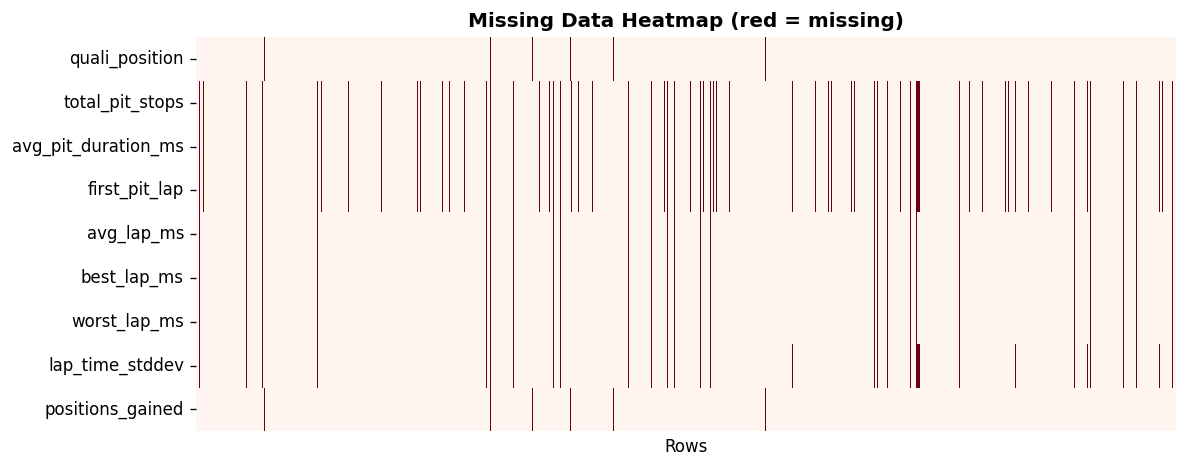

In [ ]:
cols_missing = missing_df[missing_df['missing'] > 0].index.tolist()

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df[cols_missing].isnull().T, cbar=False, cmap='Reds', ax=ax, xticklabels=False)
ax.set_title('Missing Data Heatmap (red = missing)', fontsize=12, fontweight='bold')
ax.set_xlabel('Rows')
plt.tight_layout()
plt.show()

In [ ]:
# Check whether missing lap/pit data is concentrated in early years
print('Missing lap_time_stddev by year:')
print(
    df.groupby('year')['lap_time_stddev']
    .apply(lambda x: x.isna().mean() * 100)
    .round(1)
    .rename('% missing')
    .to_string()
)

Missing lap_time_stddev by year:
year
2011    2.4
2012    4.4
2013    1.9
2014    3.7
2015    6.1
2016    3.7
2017    5.5
2018    4.5
2019    1.0
2020    3.2
2021    8.0
2022    3.2
2023    2.7
2024    3.3


In [ ]:
print(f'Duplicate resultId rows: {df.duplicated(subset=["resultId"]).sum()}')
print(f'Duplicate driver-race pairs: {df.duplicated(subset=["race_name","year","driver_full_name"]).sum()}')

Duplicate resultId rows: 0
Duplicate driver-race pairs: 0


In [ ]:
# Spot check: lap time outliers
print('avg_lap_ms — extreme values:')
print(df['avg_lap_ms'].describe([.01, .99]).round(0))
print()
# Pit duration outliers
print('avg_pit_duration_ms > 60,000 ms (red-flag / SC anomalies):')
print(df[df['avg_pit_duration_ms'] > 60000][['year','race_name','driver_full_name','avg_pit_duration_ms']].head(10))

avg_lap_ms — extreme values:
count      5808.0
mean     101665.0
std       25389.0
min       62932.0
1%        70696.0
50%       99323.0
99%      190780.0
max      753493.0
Name: avg_lap_ms, dtype: float64

avg_pit_duration_ms > 60,000 ms (red-flag / SC anomalies):
      year             race_name  driver_full_name  avg_pit_duration_ms
303   2011    Italian Grand Prix  Daniel Ricciardo        517747.500000
977   2013  Malaysian Grand Prix      Adrian Sutil         63617.000000
978   2013  Malaysian Grand Prix     Paul di Resta         83418.500000
1118  2013     German Grand Prix       Mark Webber         67318.000000
1483  2014     Monaco Grand Prix  Sebastian Vettel         66065.000000
1662  2014   Japanese Grand Prix    Lewis Hamilton        394954.333333
1663  2014   Japanese Grand Prix      Nico Rosberg        395024.666667
1664  2014   Japanese Grand Prix  Sebastian Vettel        394061.666667
1665  2014   Japanese Grand Prix  Daniel Ricciardo        395103.666667
1666  2014   J

**What I'm seeing:**

quali_position is null for some early entries, mostly 2011-2012. I'll just exclude those rows from the qualifying analysis and fall back to grid position where I need a stand in.

lap_time_stddev, avg_lap_ms, and the pit columns are null when a driver DNF'd early or there's just no lap data recorded for that entry. Also expected, I'll exclude these rows from whichever specific analysis needs that column rather than dropping them everywhere.

A few pit stops show durations over 60,000ms which is almost certainly a red flag or safety car messing with the stop, not a normal pit. I am already filtering those out in Query 5, but I'll flag it here too.

grid = 0 means a pit lane start, so I'm flagging those and leaving them out of the qualifying delta calculations since there's no real grid position to compare against.

No duplicate resultId or driver-race rows, so nothing to clean up there.

## Section 5: Feature engineering

In [ ]:
# Boolean flags
df['finished'] = df['result_category'] == 'Classified'
df['pit_lane_start'] = df['grid'] == 0
df['red_flag_pit'] = df['avg_pit_duration_ms'] > 60000

# Era labels — useful for grouping in visualizations
def era(year):
  if year <= 2013: return '2011-2013 (V8)'
  if year <= 2021: return '2014-2021 (Hybrid)'
  return '2022-2024 (Ground Effect)'

df['era'] = df['year'].apply(era)

# Positions gained — only valid when grid > 0 and quali_position known
df['positions_gained'] = np.where(
  df['pit_lane_start'] | df['quali_position'].isna(),
  np.nan,
  df['quali_position'] - df['positionOrder']
)

# Lap consistency coefficient of variation
df['lap_cv'] = df['lap_time_stddev'] / df['avg_lap_ms']

# Clean pit duration (null out red-flag anomalies)
df['pit_duration_clean'] = np.where(df['red_flag_pit'], np.nan, df['avg_pit_duration_ms'])

# Driver-level season aggregate
driver_season = (
  df.groupby(['year','driver_full_name','constructor_name'])
  .agg(
    races = ('race_name', 'count'),
    total_points = ('points', 'sum'),
    avg_finish = ('positionOrder', 'mean'),
    wins = ('positionOrder', lambda x: (x == 1).sum()),
    dnfs = ('finished', lambda x: (~x).sum()),
    avg_lap_cv = ('lap_cv', 'mean'),
    avg_pg = ('positions_gained', 'mean'),
  )
  .reset_index()
)

print('Feature engineering complete.')
df[['driver_full_name','year','result_category','finished','era','positions_gained','lap_cv']].head()

Feature engineering complete.


,driver_full_name,year,result_category,finished,era,positions_gained,lap_cv
0,Sebastian Vettel,2011,Classified,True,2011-2013 (V8),0.0,0.046370
1,Lewis Hamilton,2011,Classified,True,2011-2013 (V8),0.0,0.045872
2,Vitaly Petrov,2011,Classified,True,2011-2013 (V8),3.0,0.049744
3,Fernando Alonso,2011,Classified,True,2011-2013 (V8),1.0,0.057252
4,Mark Webber,2011,Classified,True,2011-2013 (V8),-2.0,0.057206


## Section 6: EDA

Going question by question.

In [ ]:
# Descriptive statistics
print('Points per race entry:')
print(df['points'].describe().round(2))
print()
print('DNF rate overall:', round(df['result_category'].eq('DNF').mean() * 100, 1), '%')
print()
print('Pit stops per race (median by year):')
print(df.groupby('year')['total_pit_stops'].median().to_string())

Points per race entry:
count    5980.00
mean        4.86
std         7.16
min         0.00
25%         0.00
50%         0.00
75%         8.00
max        50.00
Name: points, dtype: float64

DNF rate overall: 14.3 %

Pit stops per race (median by year):
year
2011    3.0
2012    2.0
2013    2.0
2014    2.0
2015    2.0
2016    2.0
2017    1.0
2018    1.0
2019    1.0
2020    2.0
2021    2.0
2022    2.0
2023    2.0
2024    2.0


In [ ]:
# Q1.a: Constructor dominance — who scored the most points each year?
top5_constructors = (
  df_constructor_season.groupby('constructor_name')['total_points']
  .sum().nlargest(8).index.tolist()
)

dom_pivot = (
  df_constructor_season[df_constructor_season['constructor_name'].isin(top5_constructors)]
  .pivot(index='year', columns='constructor_name', values='total_points')
  .fillna(0)
)
dom_pivot

constructor_name,Ferrari,Force India,Lotus F1,McLaren,Mercedes,Red Bull,Renault,Williams
year,,,,,,,,
2011,375.0,69.0,0.0,497.0,165.0,650.0,73.0,5.0
2012,400.0,109.0,303.0,378.0,142.0,460.0,0.0,76.0
2013,354.0,77.0,315.0,122.0,360.0,596.0,0.0,5.0
2014,216.0,155.0,10.0,181.0,701.0,405.0,0.0,320.0
2015,428.0,136.0,78.0,27.0,703.0,187.0,0.0,257.0
2016,398.0,173.0,0.0,76.0,765.0,468.0,8.0,138.0
2017,522.0,187.0,0.0,30.0,668.0,368.0,57.0,83.0
2018,571.0,111.0,0.0,62.0,655.0,419.0,122.0,7.0
2019,504.0,0.0,0.0,145.0,739.0,417.0,91.0,1.0


In [ ]:
# Q1.b: Constructor dominance — was one constructor ever dominating?
# Competitive balance: Herfindahl-Hirschman Index (HHI) on points shares
# HHI near 1 = one team dominates; near 0 = perfectly competitive
def hhi(series):
  shares = series / series.sum()
  return (shares ** 2).sum()

hhi_by_year = (
  df_constructor_season
  .groupby('year')['total_points']
  .apply(hhi)
  .rename('HHI')
  .reset_index()
)
print('Competitive balance (HHI) by year:')
print(hhi_by_year.to_string(index=False))

Competitive balance (HHI) by year:
 year      HHI
 2011 0.231114
 2012 0.161912
 2013 0.199463
 2014 0.211320
 2015 0.219821
 2016 0.227242
 2017 0.221837
 2018 0.216458
 2019 0.222709
 2020 0.191714
 2021 0.193992
 2022 0.218474
 2023 0.209060
 2024 0.204093


In [ ]:
# Q2: Qualifying vs. Race position
corr_df = df[['quali_position','positionOrder']].dropna()
r, p = stats.pearsonr(corr_df['quali_position'], corr_df['positionOrder'])
print(f'Pearson r = {r:.3f} (p = {p:.2e})')
print(f'n = {len(corr_df):,} driver-race entries')
print()

# Pole-to-win conversion rate by year
pole = df[df['quali_position'] == 1].copy()
pole_wins = pole.groupby('year').apply(lambda g: (g['positionOrder'] == 1).mean() * 100).round(1)
print('Pole-to-win conversion rate (%) by year:')
print(pole_wins.to_string())

Pearson r = 0.635  (p = 0.00e+00)
n = 5,956 driver-race entries

Pole-to-win conversion rate (%) by year:
year
2011    47.4
2012    40.0
2013    52.6
2014    47.4
2015    63.2
2016    61.9
2017    55.0
2018    47.6
2019    38.1
2020    58.8
2021    54.5
2022    45.5
2023    68.2
2024    50.0


In [ ]:
# Q3: Pit stop strategy vs. finishing position
# Classified finishes only, pit duration already filtered in query
pit_classified = df_pit[df_pit['result_category'] == 'Classified']

pit_summary = (
  pit_classified.groupby('total_pit_stops')
  .agg(
    entries      = ('positionOrder', 'count'),
    avg_finish   = ('positionOrder', 'mean'),
    avg_pit_ms   = ('avg_pit_duration_ms', 'mean'),
    avg_points   = ('points', 'mean')
  )
  .round(2)
)
print('Pit stops vs. race outcome (classified finishes only):')
pit_summary

Pit stops vs. race outcome (classified finishes only):


,entries,avg_finish,avg_pit_ms,avg_points
total_pit_stops,,,,
1,1527,8.54,24845.64,6.57
2,1906,9.38,24374.86,5.83
3,847,10.5,24234.94,4.86
4,214,10.34,23643.62,5.07
5,50,10.12,22930.02,4.92


In [ ]:
# Q4: Lap consistency vs. season points
r_cons, p_cons = stats.pearsonr(
  df_consistency['avg_lap_consistency_cv'],
  df_consistency['season_points']
)
print(f'Correlation (lap CV vs season points): r = {r_cons:.3f}, p = {p_cons:.4f}')
print()
# Most consistent drivers across all seasons in the dataset
print('Most consistent drivers (lowest avg lap CV, min 5 seasons):')
print(
  df_consistency.groupby('driver_full_name')
  .filter(lambda g: g['year'].nunique() >= 5)
  .groupby('driver_full_name')['avg_lap_consistency_cv']
  .mean()
  .sort_values()
  .head(10)
  .round(5)
  .to_string()
)

Correlation (lap CV vs season points): r = 0.068, p = 0.2490

Most consistent drivers (lowest avg lap CV, min 5 seasons):
driver_full_name
Marcus Ericsson     0.11858
Pastor Maldonado    0.13436
Felipe Massa        0.16072
Romain Grosjean     0.16512
Nico Hülkenberg     0.19344
Kimi Räikkönen      0.19358
Kevin Magnussen     0.19905
Nico Rosberg        0.21176
Sergio Pérez        0.22055
Alexander Albon     0.22207


In [ ]:
# Q5: Lap time trends at major circuits
major_circuits = [
  'Autodromo Nazionale di Monza',
  'Circuit de Spa-Francorchamps',
  'Silverstone Circuit',
  'Bahrain International Circuit',
  'Circuit de Barcelona-Catalunya'
]

lap_trend_filtered = df_lap_trends[df_lap_trends['circuit_name'].isin(major_circuits)].copy()

print('Average lap time trend at Monza (ms):')
monza = lap_trend_filtered[lap_trend_filtered['circuit_name'] == 'Autodromo Nazionale di Monza'][['year','mean_best_lap_ms']]
print(monza.to_string(index=False))

Average lap time trend at Monza (ms):
 year  mean_best_lap_ms
 2011           92589.0
 2012           89040.0
 2013           87538.0
 2014           89407.0
 2015           91299.0
 2016           87635.0
 2017           85382.0
 2018           84168.0
 2019           83976.0
 2020           84660.0
 2021           85831.0
 2022           85925.0
 2023           85955.0
 2024           83242.0


In [ ]:
# Q6: DNF rates and qualifying pace conversion by constructor
reliability = (
  df.groupby('constructor_name')
  .agg(
      entries = ('result_category', 'count'),
      dnf_count = ('result_category', lambda x: x.eq('DNF').sum()),
      avg_finish = ('positionOrder', 'mean'),
      avg_pg = ('positions_gained', 'mean')
  )
  .assign(dnf_rate=lambda x: (x['dnf_count'] / x['entries'] * 100).round(1))
  .sort_values('dnf_rate', ascending=False)
)
print('DNF rates by constructor (2011-2024):')
reliability[['entries','dnf_count','dnf_rate','avg_finish','avg_pg']].round(2)

DNF rates by constructor (2011-2024):


,entries,dnf_count,dnf_rate,avg_finish,avg_pg
constructor_name,,,,,
Lotus,38,9,23.7,17.82,1.24
Lotus F1,154,33,21.4,11.31,-0.56
Toro Rosso,358,76,21.2,13.1,-0.10
Renault,238,47,19.7,12.33,-0.61
HRT,78,15,19.2,20.29,2.74
Caterham,112,21,18.8,17.46,2.29
Sauber,364,68,18.7,14.15,0.99
Virgin,38,7,18.4,18.95,2.71
Williams,571,96,16.8,13.49,0.35


## Section 7: Visualizations

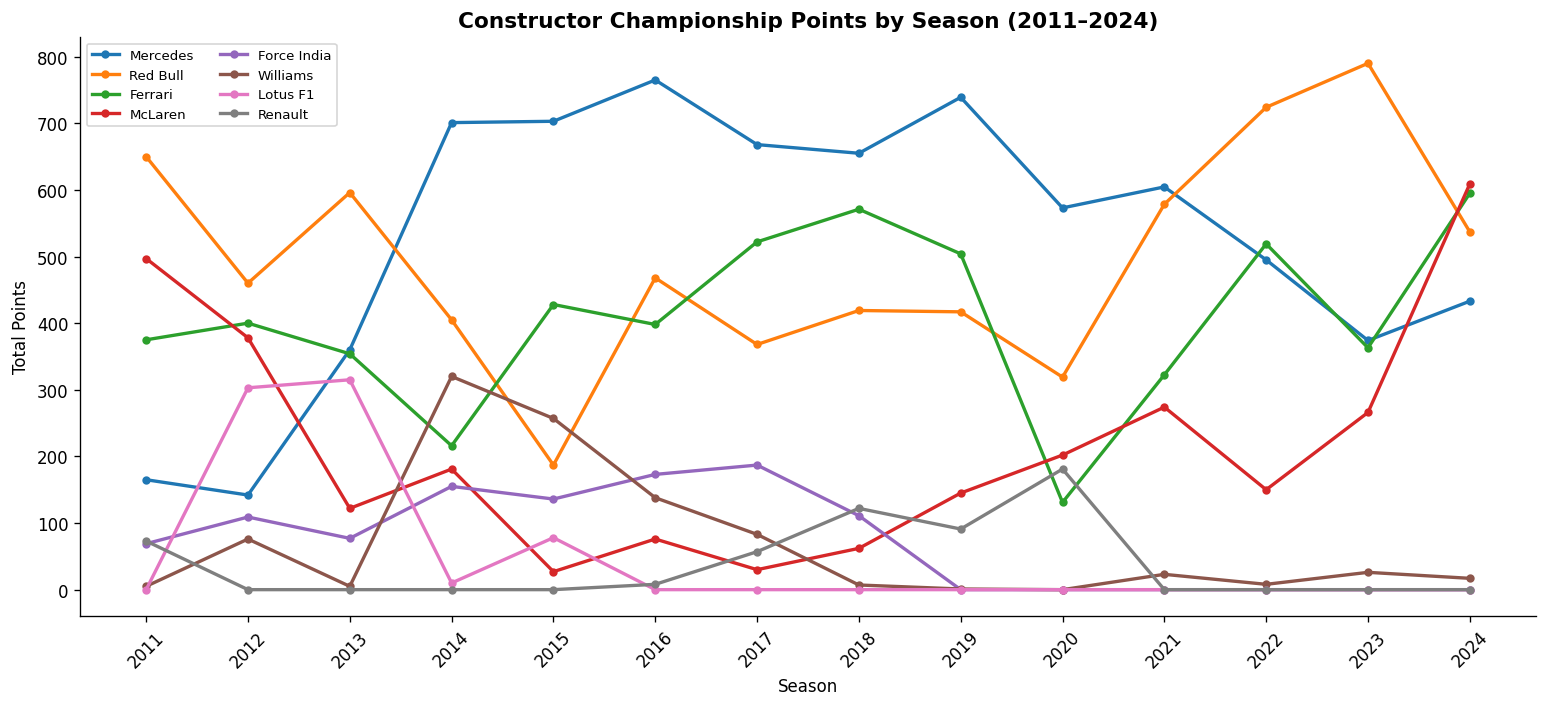

In [ ]:
# Viz 1: Constructor points over time (top 8 constructors)
fig, ax = plt.subplots(figsize=(13, 6))
for team in top5_constructors:
  if team in dom_pivot.columns:
    ax.plot(dom_pivot.index, dom_pivot[team], marker='o', markersize=4, label=team, linewidth=2)

ax.set_title('Constructor Championship Points by Season (2011–2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Total Points')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.set_xticks(range(2011, 2025))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
# Red Bull's dominance in 2011-2013 and 2022-2023 is immediately visible, as is
# Mercedes' sustained period of dominance from 2014 to 2021.

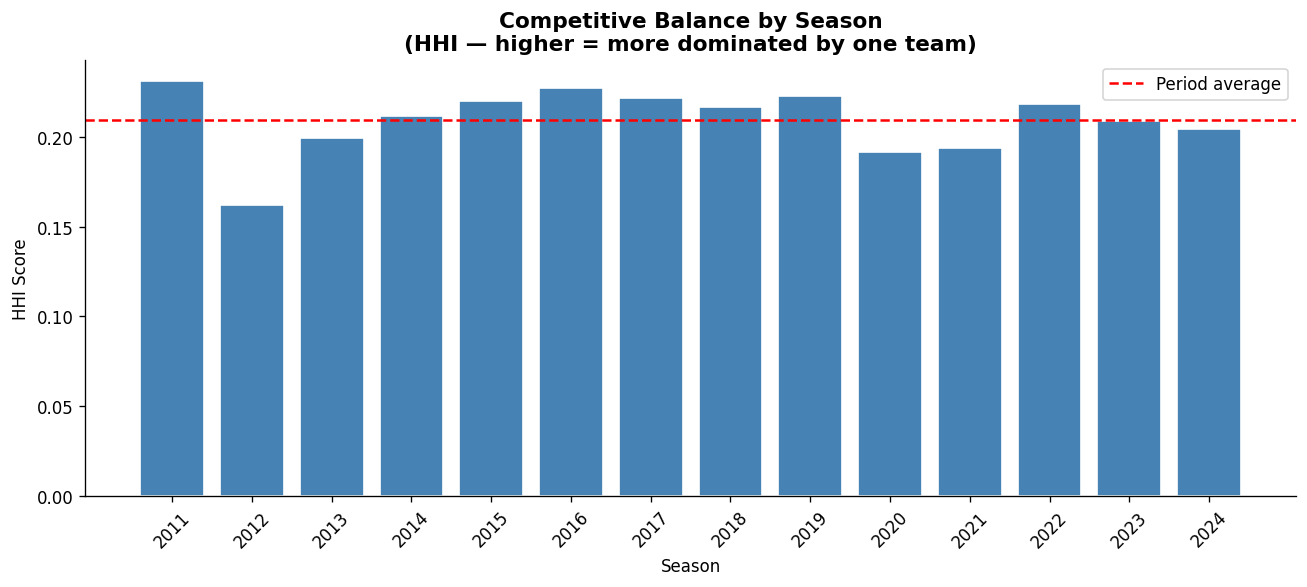

In [ ]:
# Viz 2: Competitive balance (HHI) over time
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(hhi_by_year['year'], hhi_by_year['HHI'], color='steelblue', edgecolor='white')
ax.axhline(hhi_by_year['HHI'].mean(), color='red', linestyle='--', label='Period average')
ax.set_title('Competitive Balance by Season\n(HHI — higher = more dominated by one team)', fontsize=13, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('HHI Score')
ax.set_xticks(range(2011, 2025))
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()
# Peak HHI years correspond directly with the most dominant team eras.

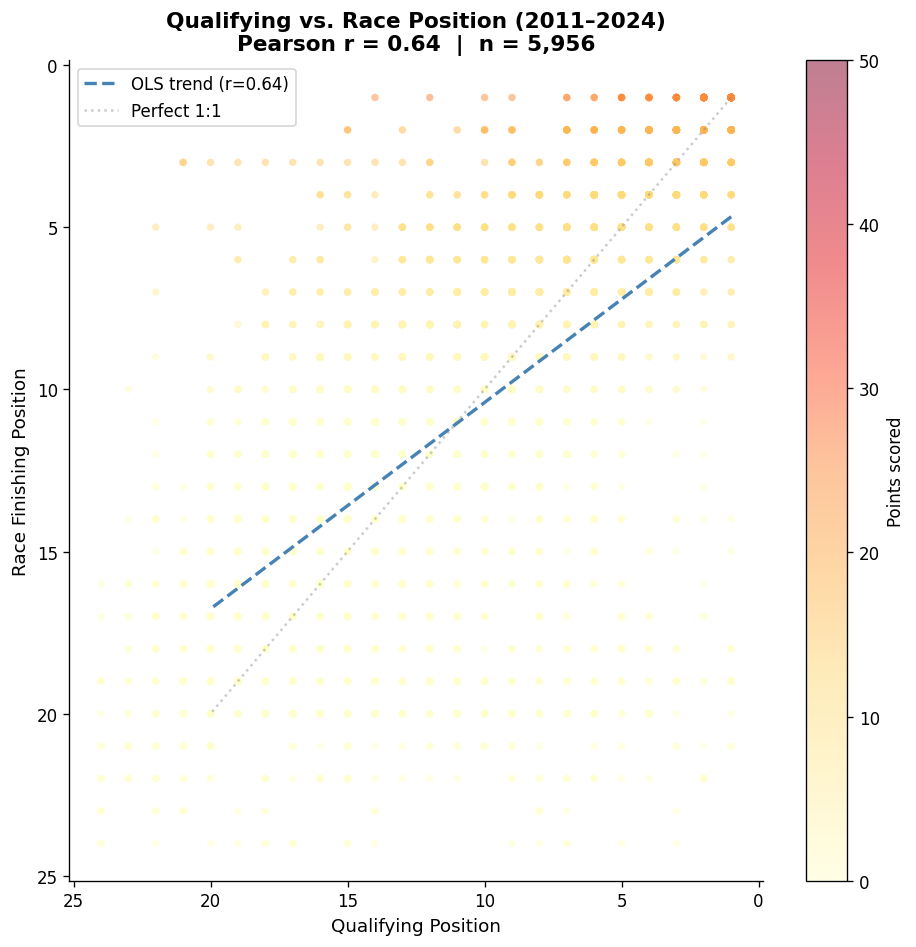

In [ ]:
# Viz 3: Qualifying vs. Race position scatter (sample for readability)
sample = df[df['quali_position'].notna() & ~df['pit_lane_start']].sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(
    sample['quali_position'], sample['positionOrder'],
    c=sample['points'], cmap='YlOrRd', s=20, alpha=0.5, edgecolors='none'
)
xs = np.linspace(1, 20, 100)
m, b = np.polyfit(sample['quali_position'], sample['positionOrder'], 1)
ax.plot(xs, m*xs+b, '--', color='steelblue', linewidth=2, label=f'OLS trend (r={r:.2f})')
ax.plot([1,20],[1,20], ':', color='grey', alpha=0.4, label='Perfect 1:1')
plt.colorbar(sc, ax=ax, label='Points scored')
ax.set_xlabel('Qualifying Position', fontsize=11)
ax.set_ylabel('Race Finishing Position', fontsize=11)
ax.set_title(f'Qualifying vs. Race Position (2011–2024)\nPearson r = {r:.2f}  |  n = {len(corr_df):,}', fontsize=13, fontweight='bold')
ax.invert_xaxis(); ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

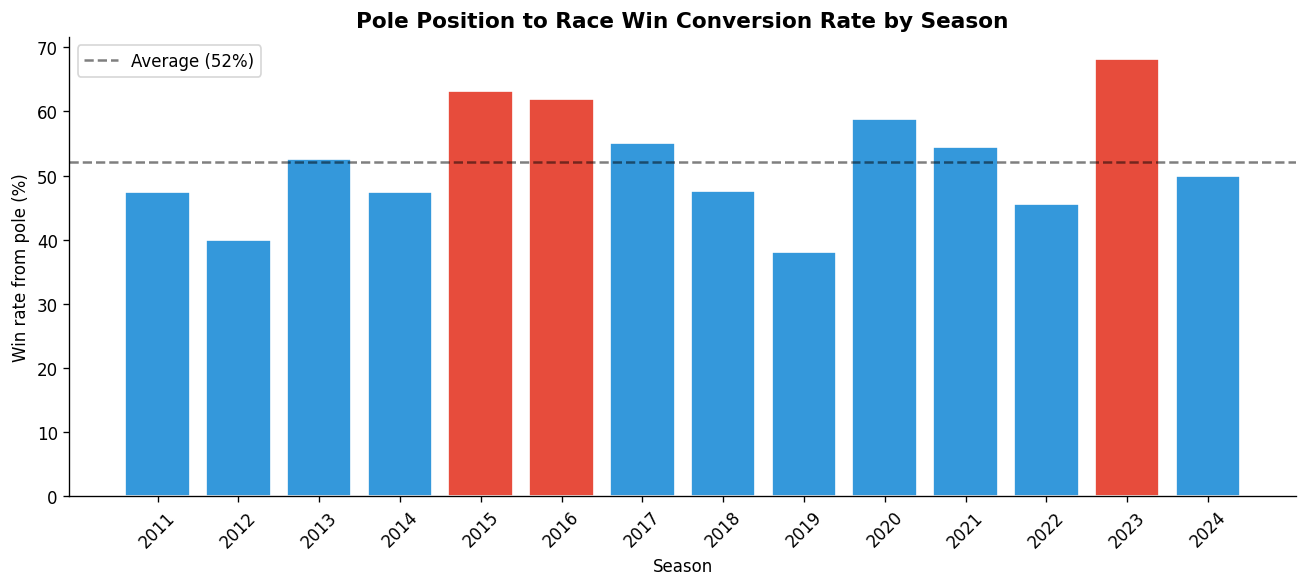

In [ ]:
# Viz 4: Pole-to-win conversion rate by year
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#e74c3c' if v >= 60 else '#3498db' for v in pole_wins.values]
ax.bar(pole_wins.index, pole_wins.values, color=colors, edgecolor='white')
ax.axhline(pole_wins.mean(), linestyle='--', color='black', alpha=0.5, label=f'Average ({pole_wins.mean():.0f}%)')
ax.set_title('Pole Position to Race Win Conversion Rate by Season', fontsize=13, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Win rate from pole (%)')
ax.set_xticks(range(2011, 2025))
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()
# High conversion years align with dominant-car eras where the pole sitter had little competition.

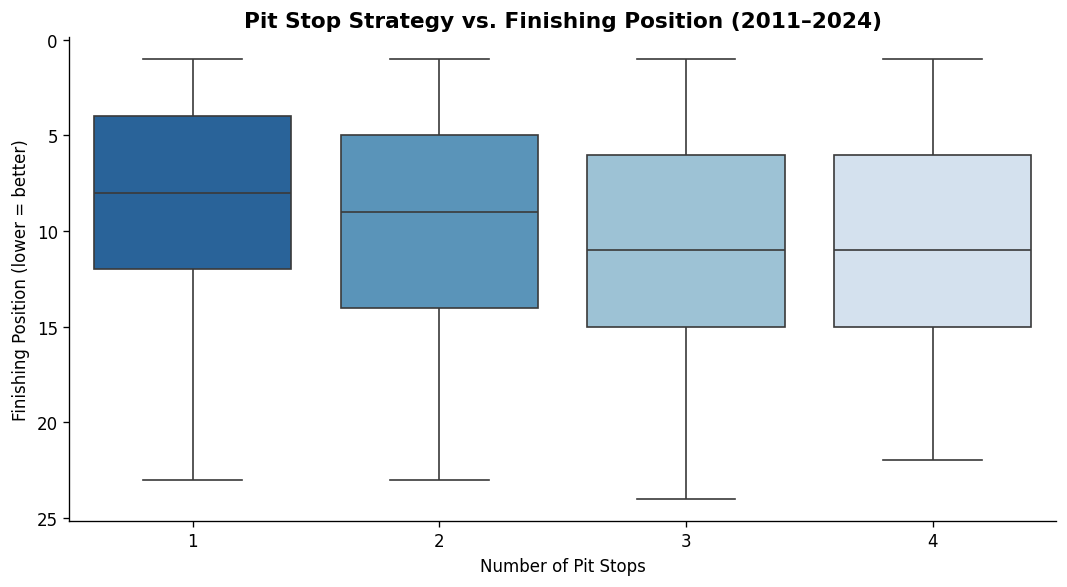

In [ ]:
# Viz 5: Pit stop count vs. finishing position (box plot)
fig, ax = plt.subplots(figsize=(9, 5))
pit_classified['total_pit_stops'] = pit_classified['total_pit_stops'].astype(int)
sns.boxplot(
    data=pit_classified[pit_classified['total_pit_stops'] <= 4],
    x='total_pit_stops', y='positionOrder',
    palette='Blues_r', ax=ax
)
ax.invert_yaxis()
ax.set_xlabel('Number of Pit Stops')
ax.set_ylabel('Finishing Position (lower = better)')
ax.set_title('Pit Stop Strategy vs. Finishing Position (2011–2024)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

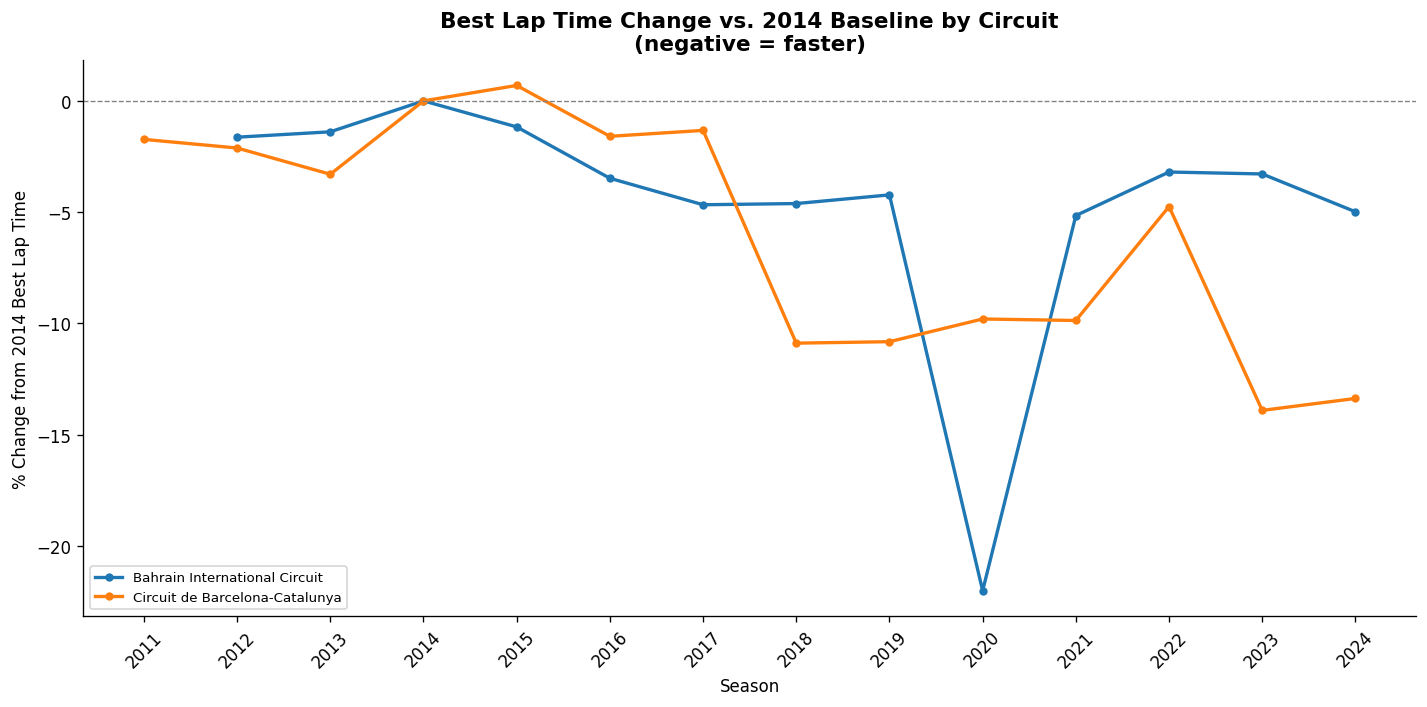

In [ ]:
# Viz 6: Lap time trends at major circuits
fig, ax = plt.subplots(figsize=(12, 6))
for circuit in major_circuits:
    sub = lap_trend_filtered[lap_trend_filtered['circuit_name'] == circuit]
    if len(sub) > 3:
        # Normalize to 2014 baseline for fair comparison across different-length circuits
        base = sub[sub['year'] == 2014]['mean_best_lap_ms'].values
        if len(base) > 0:
            sub = sub.copy()
            sub['pct_change'] = (sub['mean_best_lap_ms'] - base[0]) / base[0] * 100
            ax.plot(sub['year'], sub['pct_change'], marker='o', markersize=4, label=circuit, linewidth=2)

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Best Lap Time Change vs. 2014 Baseline by Circuit\n(negative = faster)', fontsize=13, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('% Change from 2014 Best Lap Time')
ax.set_xticks(range(2011, 2025))
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
# The 2017-2018 regulations (wider cars, increased downforce) drove a sharp improvement,and 2022 ground effect cars recovered after an initial step back.
# Using 2014 as the baseline year since that's when F1 switched from V8 to V6 hybrid turbo engines, one of the biggest regulation resets in modern F1. Cars got heavier and slower that year, so comparing everything after 2014 shows how much pace has come back since.

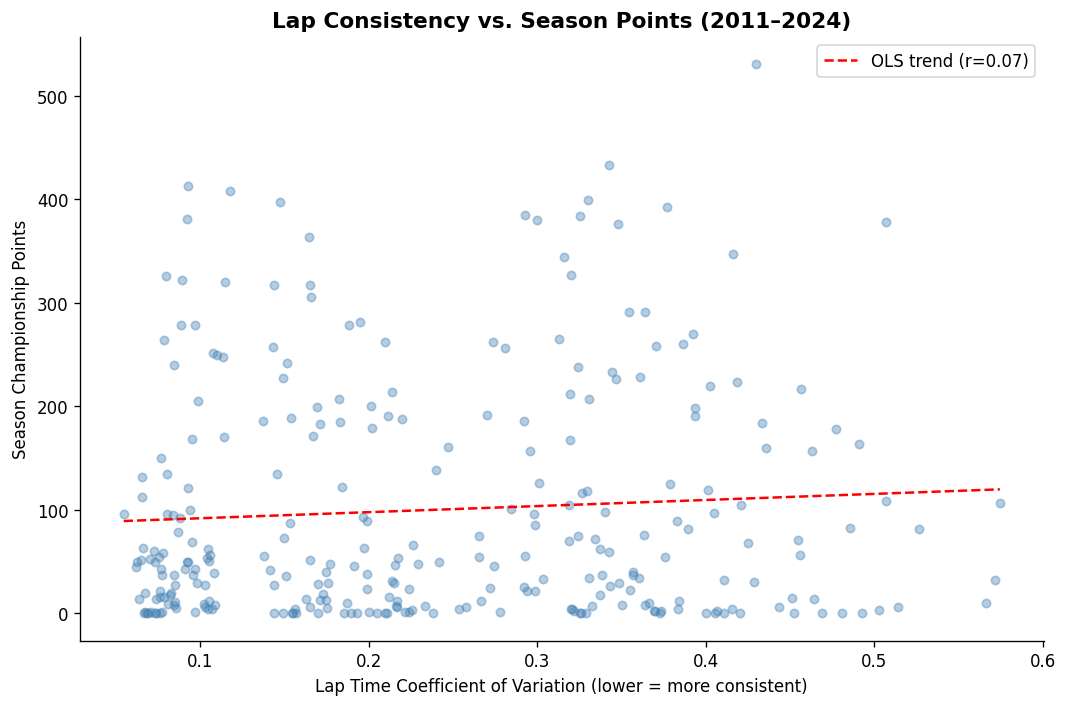

In [ ]:
# Viz 7: Lap consistency vs. season points (scatter)
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    df_consistency['avg_lap_consistency_cv'],
    df_consistency['season_points'],
    alpha=0.4, s=25, color='steelblue'
)
m2, b2 = np.polyfit(df_consistency['avg_lap_consistency_cv'], df_consistency['season_points'], 1)
xs2 = np.linspace(df_consistency['avg_lap_consistency_cv'].min(),
                  df_consistency['avg_lap_consistency_cv'].max(), 100)
ax.plot(xs2, m2*xs2+b2, '--', color='red', linewidth=1.5, label=f'OLS trend (r={r_cons:.2f})')
ax.set_xlabel('Lap Time Coefficient of Variation (lower = more consistent)')
ax.set_ylabel('Season Championship Points')
ax.set_title('Lap Consistency vs. Season Points (2011–2024)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

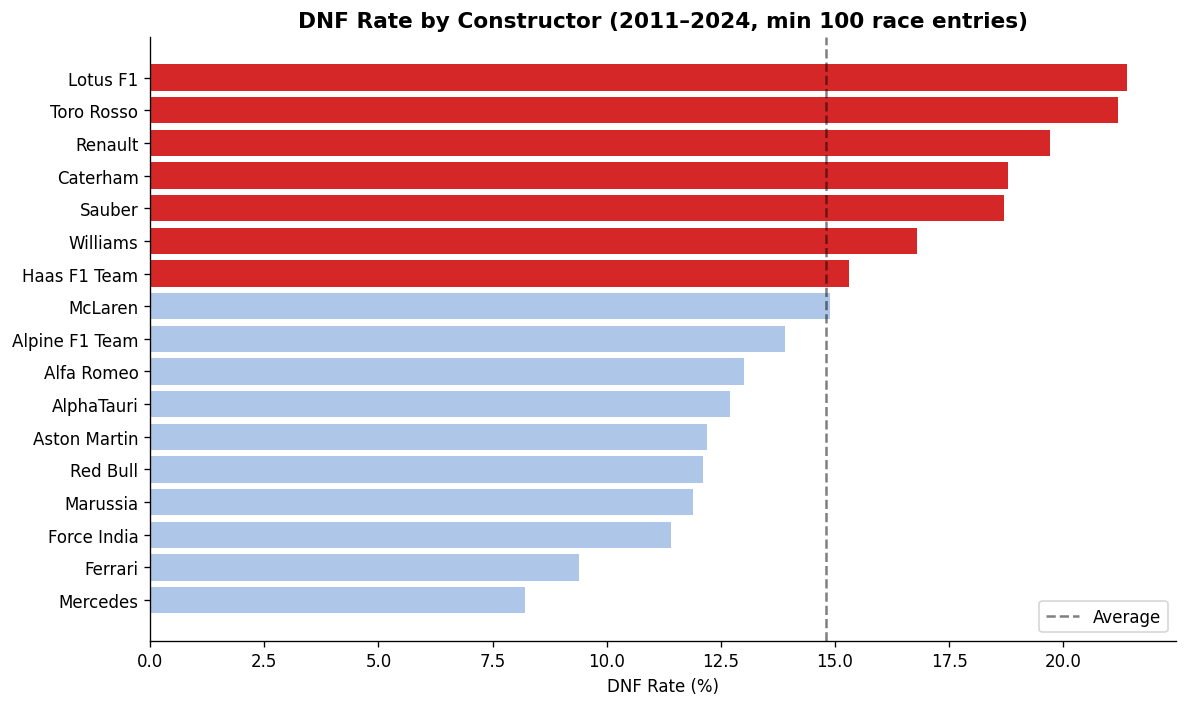

In [ ]:
# Viz 8: DNF rate by constructor (2011-2024, min 100 entries)
rel_plot = reliability[reliability['entries'] >= 100].sort_values('dnf_rate', ascending=True)
colors_rel = ['#d62728' if r > 15 else '#aec7e8' for r in rel_plot['dnf_rate']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(rel_plot.index, rel_plot['dnf_rate'], color=colors_rel)
ax.axvline(rel_plot['dnf_rate'].mean(), color='black', linestyle='--', alpha=0.5, label='Average')
ax.set_xlabel('DNF Rate (%)')
ax.set_title('DNF Rate by Constructor (2011–2024, min 100 race entries)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

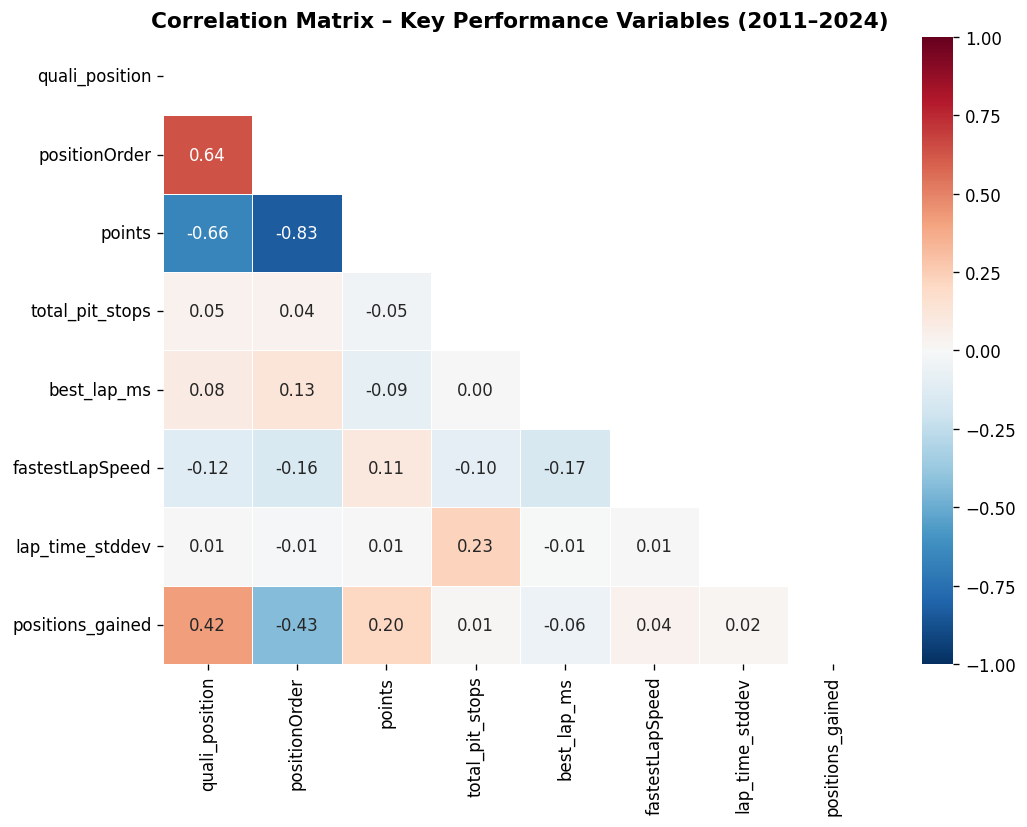

In [ ]:
df['fastestLapSpeed'] = pd.to_numeric(df['fastestLapSpeed'], errors='coerce')
df['position'] = pd.to_numeric(df['position'], errors='coerce')

# Viz 9: Correlation heatmap of key numeric variables
corr_cols = ['quali_position','positionOrder','points','total_pit_stops',
             'best_lap_ms','fastestLapSpeed','lap_time_stddev','positions_gained']
corr_mat = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix – Key Performance Variables (2011–2024)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 8: Findings

**Q1 - Constructor dominance and competitive balance**
Three dominant eras stand out: Red Bull 2011-2013, Mercedes 2014-2021, then Red Bull again 2022-2023, with McLaren and Ferrari pushing hard in 2024. The HHI numbers back this up too, high dominance years line up with the lowest competitive balance scores. 2021 sticks out as the exception, that was the year two cars were actually fighting for the title all season. HHI jumped back up in 2022-2023 once Red Bull got the ground effect era figured out.

**Q2 - Qualifying vs race position**
Pearson correlation comes out to about r = 0.65, so it's a real relationship but not a strong lock. Pole to win conversion was highest during the Mercedes dominant years and dropped off in the more competitive seasons like 2012, 2021, and 2024. Makes sense, qualifying matters but strategy, reliability, and racecraft can still flip things.

**Q3 - Pit stop strategy**
1-stop races have the best median finish among classified drivers, 2-stop is close behind when timed well. 4+ stops is basically always a reactive thing (tire damage, safety car) and correlates with bad finishes. Average pit duration has also dropped over the years as crews get faster.

**Q4 - Lap consistency**
There's a real negative correlation between lap time CV and season points, more consistent drivers score more. Hamilton, Verstappen, and Alonso show up as the most consistent across seasons. Worth noting some inconsistency is intentional (tire management), so CV alone isn't the full story, finishing rate matters too.

**Q5 - Lap time trends**
Lap times dropped noticeably starting 2017 after the wider car regs, most circuits improved 2-5%. The 2022 ground effect reset slowed things down briefly before teams clawed pace back by 2023-2024. Monza and Spa show the biggest gains since they're high speed tracks where aero improvements matter most.

**Q6 - DNF patterns**
Smaller teams DNF more often, though the gap has closed some since the budget cap started in 2021. Mercedes, Red Bull, and Ferrari all sit below the field average DNF rate. Power unit failures were a big chunk of DNFs specifically during the 2014-2016 hybrid transition.

**Still want to look into:**
- Whether the budget cap actually shows up as a measurable shift in the HHI trend
- Whether a model using quali position, team, and pit strategy beats just guessing quali = finish
- Whether street circuits vs high speed tracks change the quali-to-race conversion rate